<a href="https://colab.research.google.com/github/dataanalytics13dtat-wq/Fase2_Machine_Learning_Applied_to_Business/blob/main/wine_quality_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tech Challenge - Fase 2
## Classificando a Qualidade de Vinhos com Machine Learning

**POSTECH - DTAT**

Pipeline: compreensao do problema -> EDA -> pre-processamento -> modelagem -> avaliacao -> interpretacao.

**Base de dados:** WineQT.csv (Kaggle, "Wine Quality Dataset"), 1143 amostras, 12 variaveis fisico-quimicas + quality (nota) + Id.

In [ ]:
# ==============================================================
# ETAPA 0 - IMPORTACOES
# ==============================================================
# Bibliotecas de manipulacao de dados
import pandas as pd
import numpy as np

# Bibliotecas de visualizacao
import matplotlib.pyplot as plt
import seaborn as sns

# scikit-learn: divisao dos dados, validacao cruzada e padronizacao
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler

# scikit-learn: os dois modelos de classificacao que vamos comparar
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Pipeline: encadeia padronizacao + modelo em um unico objeto (usado na validacao cruzada)
from sklearn.pipeline import make_pipeline

# Metricas de avaliacao de classificacao
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix, classification_report)

# Evita que warnings tecnicos (nao criticos) poluam a saida do notebook
import warnings
warnings.filterwarnings("ignore")

# Configuracoes visuais padrao para todos os graficos do notebook
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# Semente fixa de aleatoriedade: garante que, ao rodar o notebook de novo,
# a divisao treino/teste e o treinamento dos modelos deem exatamente o mesmo resultado
RANDOM_STATE = 42


## 1. Compreensao do Problema

- Contexto: prever a qualidade de vinhos tintos a partir de variaveis fisico-quimicas, para apoiar decisoes de producao sem depender apenas de avaliacao sensorial subjetiva.
- Variavel alvo: quality (nota de especialistas, escala original 0-10).
- Transformacao em classificacao binaria:
  - Vinho de Alta Qualidade: nota >= 7 -> classe 1
  - Vinho de Baixa/Media Qualidade: nota < 7 -> classe 0

In [ ]:
# ==============================================================
# ETAPA 1 - CARREGAR OS DADOS E DEFINIR A VARIAVEL ALVO
# ==============================================================

# Le o CSV completo (1143 linhas, 13 colunas: 11 variaveis fisico-quimicas + quality + Id)
df = pd.read_csv("WineQT.csv")

# O Id e apenas um identificador sequencial da linha, sem poder preditivo -> removemos
df = df.drop(columns=["Id"])

# Cria a variavel alvo binaria pedida pelo desafio:
#   quality >= 7  -> 1 (Alta Qualidade)
#   quality <  7  -> 0 (Baixa/Media Qualidade)
# np.where funciona como um "SE" vetorizado: testa a condicao para cada linha de uma vez
df["quality_label"] = np.where(df["quality"] >= 7, 1, 0)

# Checagem rapida: quantas linhas/colunas temos e como sao as primeiras linhas
print(df.shape)
df.head()


(1143, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,quality_label
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0


## 2. Analise Exploratoria de Dados (EDA)

### 2.1 Distribuicao das variaveis

In [ ]:
# describe() calcula, para cada coluna numerica: contagem, media, desvio padrao,
# minimo, quartis (25%/50%/75%) e maximo. E o primeiro raio-x dos dados.
# .T (transposta) so inverte linhas/colunas para ficar mais facil de ler.
df.describe().T


,count,mean,std,min,25%,50%,75%,max
fixed acidity,1143.0,8.311111,1.747595,4.60000,7.10000,7.90000,9.100000,15.90000
volatile acidity,1143.0,0.531339,0.179633,0.12000,0.39250,0.52000,0.640000,1.58000
citric acid,1143.0,0.268364,0.196686,0.00000,0.09000,0.25000,0.420000,1.00000
residual sugar,1143.0,2.532152,1.355917,0.90000,1.90000,2.20000,2.600000,15.50000
chlorides,1143.0,0.086933,0.047267,0.01200,0.07000,0.07900,0.090000,0.61100
free sulfur dioxide,1143.0,15.615486,10.250486,1.00000,7.00000,13.00000,21.000000,68.00000
total sulfur dioxide,1143.0,45.914698,32.782130,6.00000,21.00000,37.00000,61.000000,289.00000
density,1143.0,0.996730,0.001925,0.99007,0.99557,0.99668,0.997845,1.00369
pH,1143.0,3.311015,0.156664,2.74000,3.20500,3.31000,3.400000,4.01000
sulphates,1143.0,0.657708,0.170399,0.33000,0.55000,0.62000,0.730000,2.00000


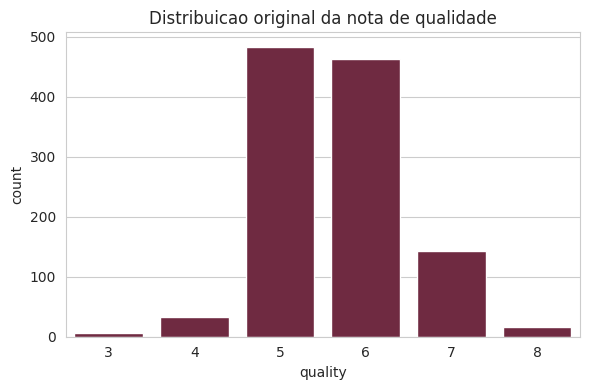

In [ ]:
# Grafico de barras mostrando quantos vinhos existem em cada nota original (3 a 8)
# Isso ajuda a visualizar o desbalanceamento ANTES de binarizar a variavel
plt.figure(figsize=(6, 4))
sns.countplot(x="quality", data=df, color="#7b1e3d")
plt.title("Distribuicao original da nota de qualidade")
plt.tight_layout()
plt.savefig("results/00_distribuicao_quality_original.png", dpi=120)  # salva o grafico como imagem
plt.show()


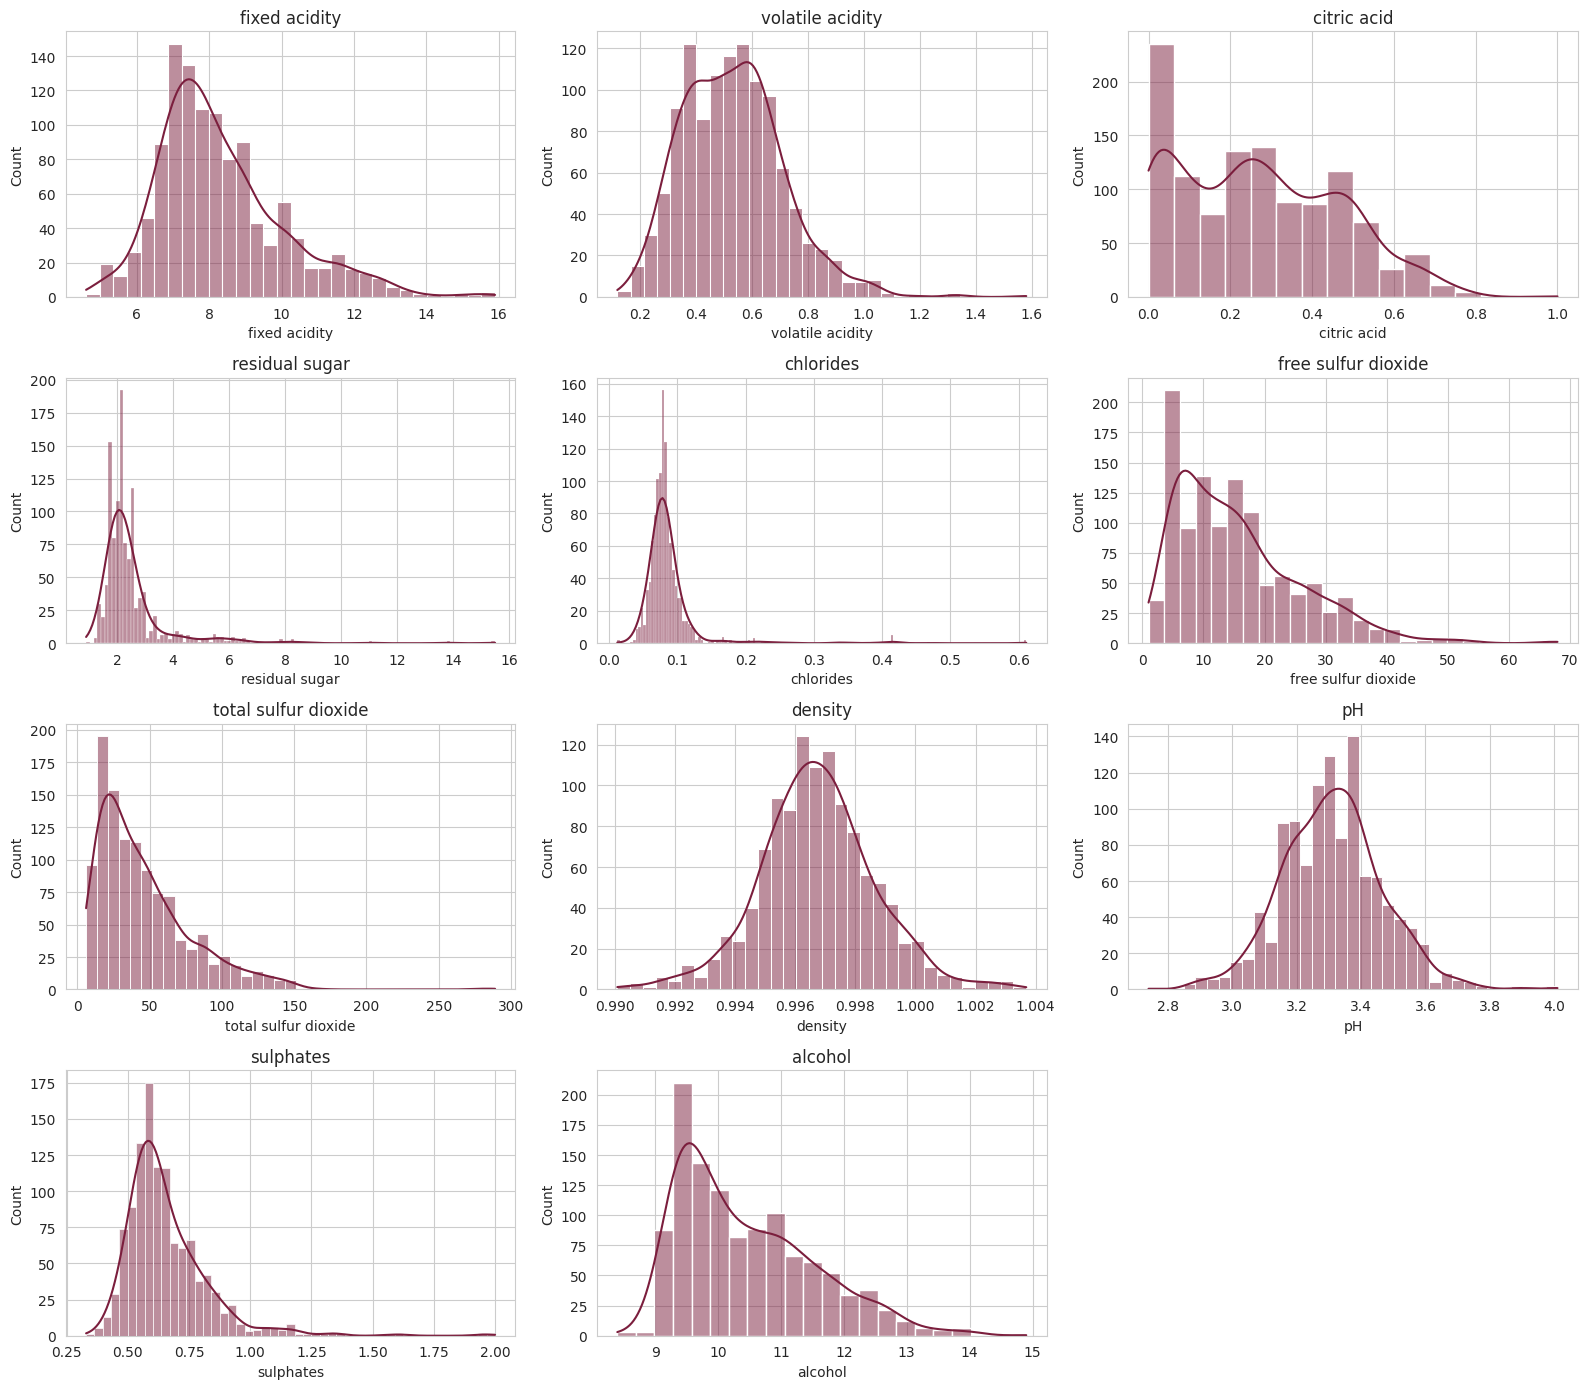

In [ ]:
# Lista com todas as colunas de entrada (features), excluindo a nota original
# e a versao binaria dela -- essas duas sao "resposta", nao "pergunta"
num_cols = [c for c in df.columns if c not in ("quality", "quality_label")]

# Cria uma grade de 4 linhas x 3 colunas de graficos (12 espacos para 11 variaveis)
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()  # transforma a grade 2D em uma lista simples, mais facil de percorrer

# Para cada variavel, desenha um histograma (barras de frequencia) com uma curva de
# densidade (KDE) sobreposta, que suaviza o formato da distribuicao
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color="#7b1e3d")
    axes[i].set_title(col)

# Remove os quadros vazios que sobraram na grade (temos 11 variaveis para 12 espacos)
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("results/01_distribuicoes.png", dpi=120)
plt.show()


### 2.2 Balanceamento das classes

quality_label
0    984
1    159
Name: count, dtype: int64
quality_label
0    86.1%
1    13.9%
Name: count, dtype: object


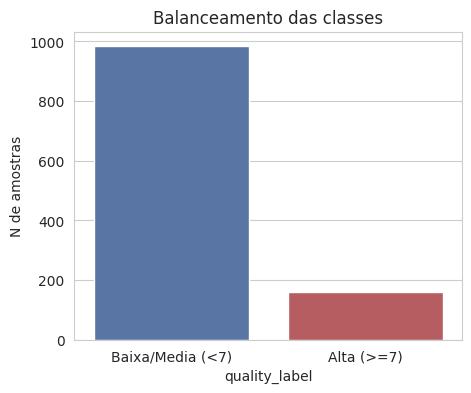

In [ ]:
# Conta quantas linhas existem em cada classe (0 = Baixa/Media, 1 = Alta)
counts = df["quality_label"].value_counts().sort_index()
print(counts)

# Mesma contagem, mas em percentual do total -- deixa o desbalanceamento mais evidente
print((counts / counts.sum() * 100).round(1).astype(str) + "%")

# Grafico de barras comparando visualmente as duas classes
plt.figure(figsize=(5,4))
sns.barplot(x=counts.index.map({0: "Baixa/Media (<7)", 1: "Alta (>=7)"}), y=counts.values, palette=["#4c72b0", "#c44e52"])
plt.ylabel("N de amostras")
plt.title("Balanceamento das classes")
plt.savefig("results/02_balanceamento_classes.png", dpi=120)
plt.show()


Observacao: a classe "Alta Qualidade" e minoritaria (~14% da base) - desbalanceamento real, nao artefato de amostra pequena. Usamos class_weight="balanced" nos modelos e recall/F1/ROC-AUC (nao so acuracia) na avaliacao, ja que acuracia sozinha e enganosa em bases desbalanceadas.

### 2.3 Correlacoes entre variaveis

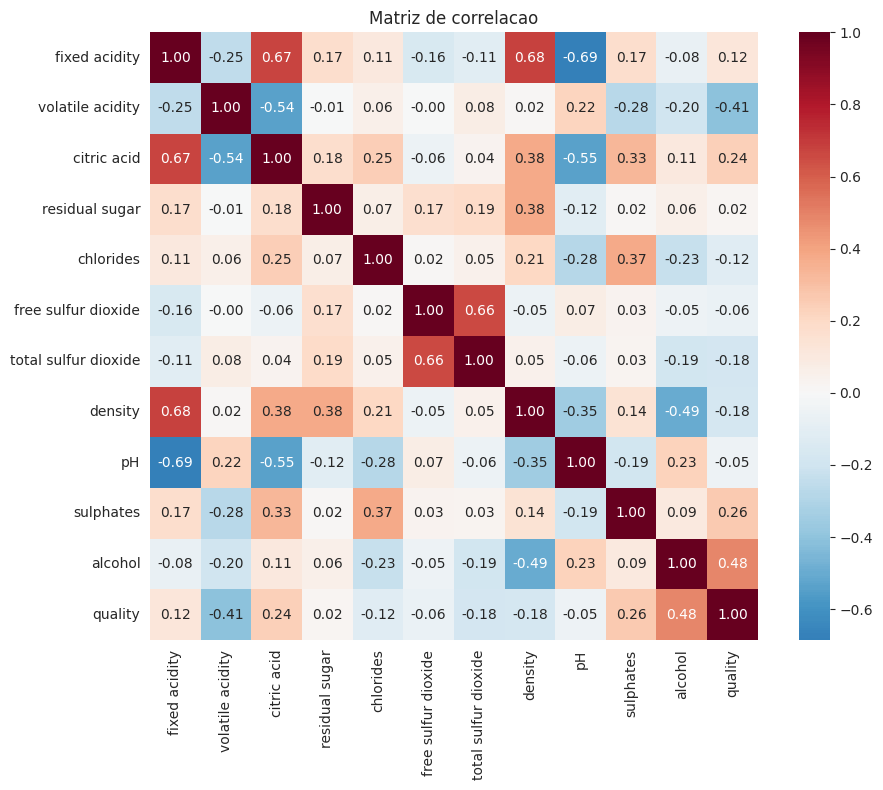

quality                 1.000000
alcohol                 0.484866
sulphates               0.257710
citric acid             0.240821
fixed acidity           0.121970
residual sugar          0.022002
pH                     -0.052453
free sulfur dioxide    -0.063260
chlorides              -0.124085
density                -0.175208
total sulfur dioxide   -0.183339
volatile acidity       -0.407394
Name: quality, dtype: float64

In [ ]:
# corr() calcula o coeficiente de correlacao de Pearson entre cada par de variaveis:
# vai de -1 (uma sobe quando a outra desce, sempre) a +1 (as duas sobem/descem juntas, sempre)
corr = df[num_cols + ["quality"]].corr()

# Heatmap (mapa de calor): visualiza a matriz de correlacao inteira de uma vez,
# com cores indicando forca e direcao da correlacao
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True)
plt.title("Matriz de correlacao")
plt.tight_layout()
plt.savefig("results/03_correlacoes.png", dpi=120)
plt.show()

# Ordena so a coluna "quality" da matriz, da correlacao mais positiva para a mais negativa
# -- e a forma mais rapida de ver quais variaveis mais "puxam" a nota para cima ou para baixo
corr["quality"].sort_values(ascending=False)


Leitura das correlacoes com quality (base completa, 1143 amostras):

- alcohol e a variavel com correlacao positiva mais forte - vinhos com maior teor alcoolico tendem a notas mais altas.
- volatile acidity e a correlacao negativa mais forte - acidez volatil alta esta associada a defeitos de sabor (gosto de vinagre), reduzindo a qualidade.
- sulphates e citric acid tem correlacao positiva moderada, associados a conservacao e frescor.
- density e fixed acidity/citric acid sao correlacionadas entre si (redundancia/multicolinearidade), candidatas a engenharia de features.

### 2.4 Outliers

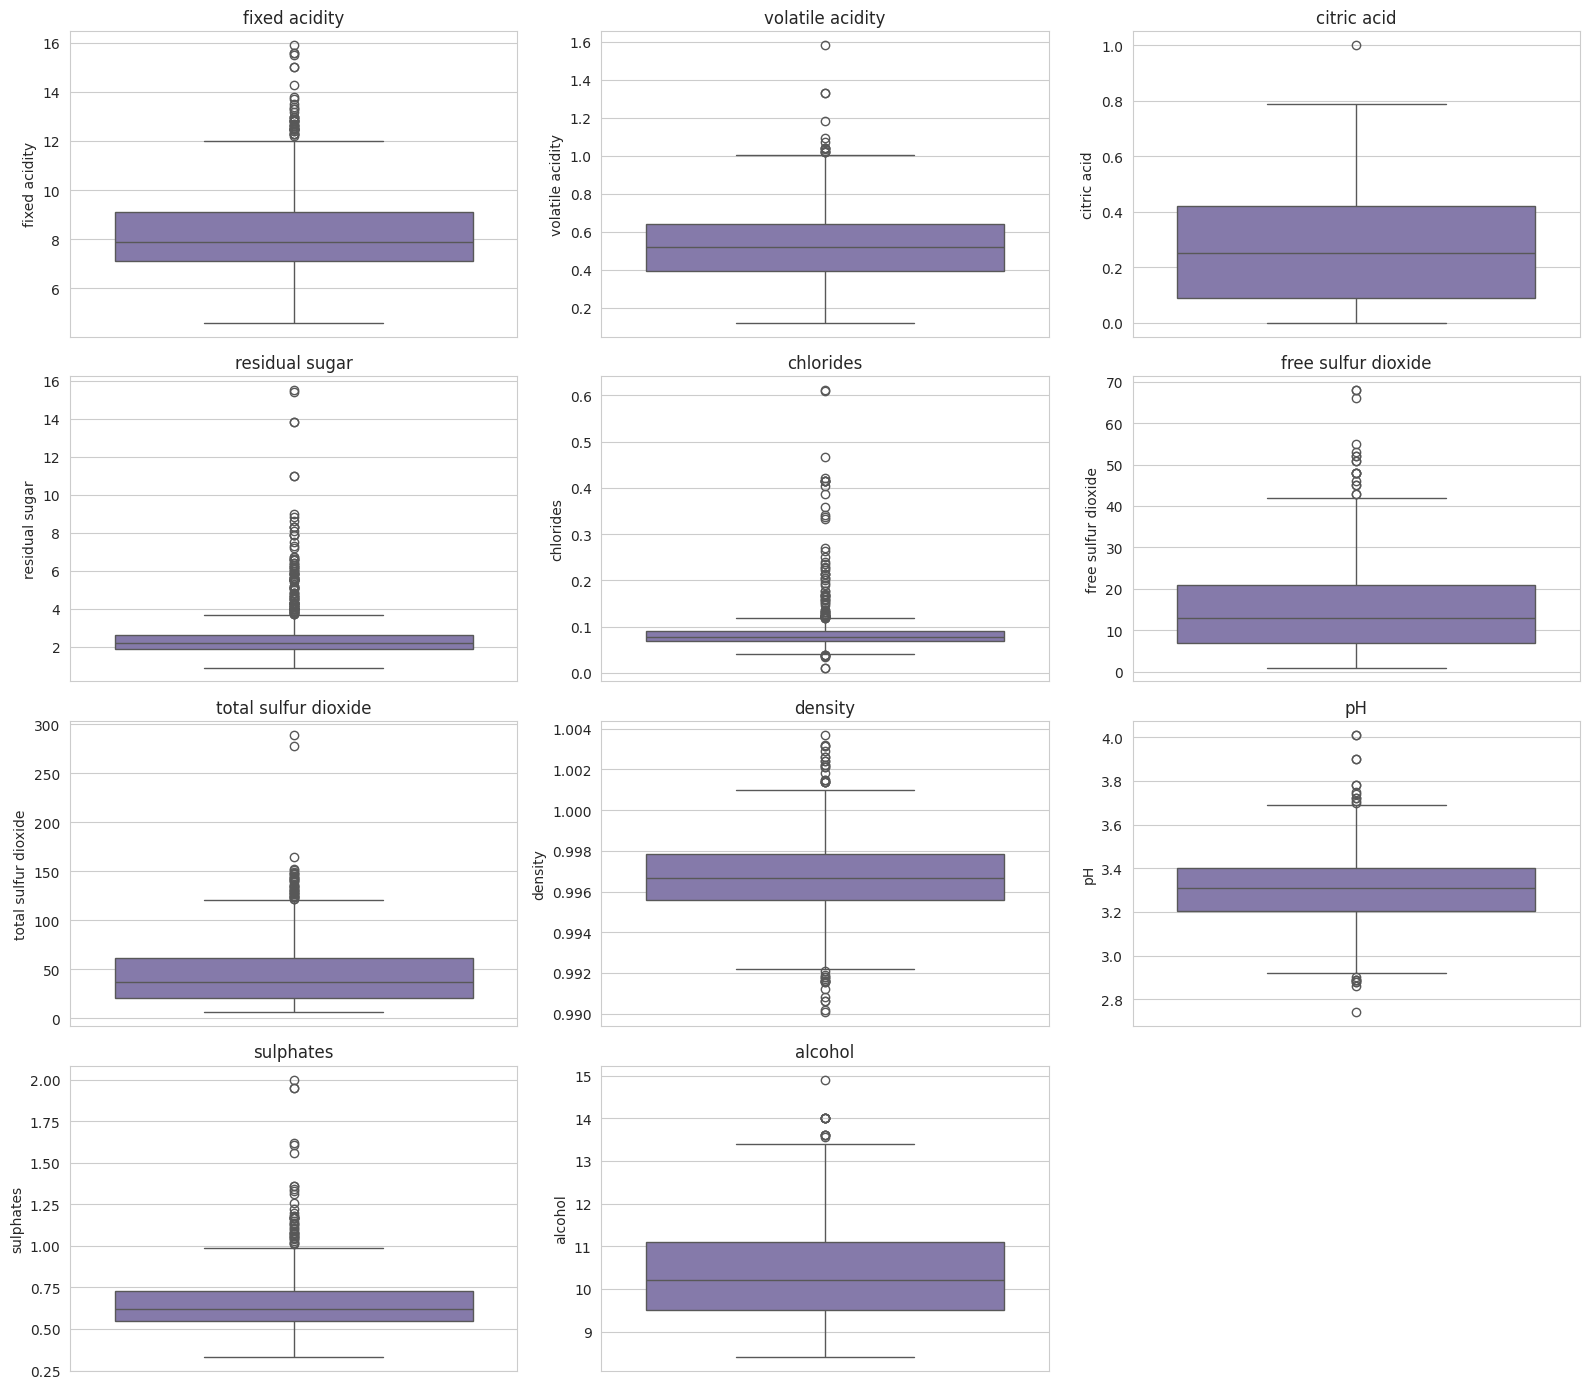

In [ ]:
# Boxplot (diagrama de caixa) por variavel: mostra mediana, quartis e os pontos
# que ficam fora do intervalo esperado (outliers), representados como pontos isolados
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i], color="#8172b2")
    axes[i].set_title(col)
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.savefig("results/04_outliers_boxplot.png", dpi=120)
plt.show()


In [ ]:
# Funcao que conta outliers pelo criterio classico do IQR (intervalo interquartil):
# 1) calcula o 1o quartil (25% dos dados abaixo) e o 3o quartil (75% dos dados abaixo)
# 2) IQR = distancia entre eles
# 3) qualquer valor mais de 1.5x o IQR abaixo do Q1 ou acima do Q3 e considerado outlier
def iqr_outliers(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    return ((series < lower) | (series > upper)).sum()

# Aplica a funcao em cada variavel numerica e ordena da que tem mais outliers para a que tem menos
outlier_counts = pd.Series({c: iqr_outliers(df[c]) for c in num_cols}).sort_values(ascending=False)
outlier_counts


residual sugar          110
chlorides                77
fixed acidity            44
sulphates                43
total sulfur dioxide     40
density                  36
pH                       20
free sulfur dioxide      18
volatile acidity         14
alcohol                  12
citric acid               1
dtype: int64

residual sugar, chlorides, sulphates e free/total sulfur dioxide concentram a maior parte dos outliers (criterio IQR - 1.5x o intervalo interquartil). Sao valores fisicamente plausiveis (lotes com maior teor de acucar ou conservantes), entao optamos por nao remover, mas sim padronizar as variaveis (proxima etapa) para reduzir a sensibilidade dos modelos lineares a essas amplitudes.

## 3. Pre-processamento de Dados

In [ ]:
# isna() marca cada celula como True (vazia) ou False (preenchida);
# sum() soma essas marcacoes por coluna, dando o total de valores faltantes de cada variavel
print("Valores faltantes por coluna:")
print(df[num_cols + ["quality"]].isna().sum())


Valores faltantes por coluna:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


Nao ha valores faltantes na base.

In [ ]:
# --------------------------------------------------------------
# Engenharia de features: criamos 2 variaveis novas a partir das existentes,
# combinando conhecimento de dominio (quimica do vinho) com os dados disponiveis
# --------------------------------------------------------------

# Proporcao de SO2 (dioxido de enxofre) livre em relacao ao total.
# So o SO2 "livre" protege o vinho de fato -- essa razao mede a eficiencia da conservacao
df["total_free_sulfur_ratio"] = df["free sulfur dioxide"] / df["total sulfur dioxide"]

# Razao entre acidez fixa e volatil. Acidez volatil alta sozinha indica defeito,
# mas o efeito depende do quanto de acidez fixa (a "boa") tambem existe no vinho
# +1e-6 evita divisao por zero em casos extremos
df["acid_balance"] = df["fixed acidity"] / (df["volatile acidity"] + 1e-6)

# Lista final de features que vao entrar nos modelos: as originais + as duas novas
engineered_cols = num_cols + ["total_free_sulfur_ratio", "acid_balance"]

# Conferindo se as novas colunas fazem sentido (nao tem valores absurdos, infinitos, etc.)
df[["total_free_sulfur_ratio", "acid_balance"]].describe()


,total_free_sulfur_ratio,acid_balance
count,1143.000000,1143.000000
mean,0.380418,18.087668
std,0.154112,9.266401
min,0.022727,4.807688
25%,0.257473,11.612884
50%,0.375000,15.102010
75%,0.478261,22.041616
max,0.857143,74.166049


- total_free_sulfur_ratio: proporcao de SO2 livre em relacao ao total - indicador de eficacia da conservacao (SO2 livre e o que efetivamente protege o vinho).
- acid_balance: relacao entre acidez fixa e volatil - tenta capturar o equilibrio de acidez, ja que acidez volatil alta isolada indica defeito, mas o contexto da acidez fixa importa.

In [ ]:
# --------------------------------------------------------------
# Separacao treino/teste + padronizacao
# --------------------------------------------------------------

# X = variaveis de entrada (features); y = variavel de saida (o que queremos prever)
X = df[engineered_cols]
y = df["quality_label"]

# Divide os dados em 70% para treinar os modelos e 30% para testar (avaliar) depois,
# em dados que o modelo nunca viu durante o treino.
# stratify=y garante que a proporcao 86%/14% das classes seja mantida em treino E teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

# StandardScaler transforma cada variavel para media 0 e desvio padrao 1.
# Necessario para a Regressao Logistica (sensivel a escala); nao afeta a Random Forest,
# mas nao faz mal usar o mesmo conjunto de dados padronizado quando precisar.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # calcula media/desvio SOMENTE no treino...
X_test_scaled = scaler.transform(X_test)        # ...e aplica a mesma transformacao no teste

# Conferindo os tamanhos e a proporcao de classes em cada conjunto
print("Treino:", X_train.shape, " Teste:", X_test.shape)
print("Distribuicao treino:")
print(y_train.value_counts())
print("Distribuicao teste:")
print(y_test.value_counts())


Treino: (800, 13)  Teste: (343, 13)
Distribuicao treino:
quality_label
0    689
1    111
Name: count, dtype: int64
Distribuicao teste:
quality_label
0    295
1     48
Name: count, dtype: int64


## 4. Desenvolvimento de Modelos

Dois modelos de classificacao, com class_weight="balanced" dado o desbalanceamento das classes:

1. Regressao Logistica - modelo linear, interpretavel via coeficientes.
2. Random Forest - modelo nao-linear, robusto a outliers, fornece importancia de variaveis.

In [ ]:
# --------------------------------------------------------------
# Treinamento dos dois modelos
# --------------------------------------------------------------

# Regressao Logistica: modelo linear que estima a PROBABILIDADE de um vinho ser "Alta Qualidade".
# class_weight="balanced" faz o modelo dar mais peso de erro aos exemplos da classe minoritaria
# (Alta Qualidade), compensando o desbalanceamento de 86%/14%.
# Usa os dados PADRONIZADOS (X_train_scaled), pois e sensivel a escala das variaveis.
log_reg = LogisticRegression(class_weight="balanced", random_state=RANDOM_STATE, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

# Random Forest: conjunto de 300 arvores de decisao, cada uma vendo uma amostra/combinacao
# diferente dos dados; a previsao final e um "voto" entre as arvores.
# Nao precisa de dados padronizados, pois arvores de decisao nao sao sensiveis a escala.
rf = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE)
rf.fit(X_train, y_train)

# Guardamos os dois modelos treinados em um dicionario, para facilitar comparar os dois
# nas proximas celulas sem repetir codigo
models = {"Regressao Logistica": log_reg, "Random Forest": rf}


## 5. Avaliacao dos Modelos

### 5.1 Split unico (treino/teste)

In [ ]:
# --------------------------------------------------------------
# Avaliacao no conjunto de teste (30% separado antes do treino)
# --------------------------------------------------------------
results = []
for name, model in models.items():
    # A Regressao Logistica precisa dos dados padronizados; a Random Forest usa os dados originais
    X_eval = X_test_scaled if name == "Regressao Logistica" else X_test

    y_pred = model.predict(X_eval)  # classe prevista (0 ou 1) para cada vinho do teste

    # predict_proba devolve a probabilidade prevista; pegamos so a probabilidade da classe 1 (Alta)
    y_proba = model.predict_proba(X_eval)[:, 1] if hasattr(model, "predict_proba") else None

    row = {
        "Modelo": name,
        "Acuracia": accuracy_score(y_test, y_pred),      # % de acertos totais
        "Precisao": precision_score(y_test, y_pred, zero_division=0),  # dos que o modelo disse "Alta", quantos eram Alta de verdade
        "Recall": recall_score(y_test, y_pred, zero_division=0),       # dos vinhos que eram Alta de verdade, quantos o modelo pegou
        "F1": f1_score(y_test, y_pred, zero_division=0),               # media harmonica entre precisao e recall
    }
    # ROC-AUC: mede a capacidade do modelo de separar as duas classes, independente do limiar de decisao
    if y_proba is not None and len(set(y_test)) > 1:
        row["ROC_AUC"] = roc_auc_score(y_test, y_proba)
    results.append(row)

# Junta tudo numa tabela, arredondando para 3 casas decimais, e salva em CSV
results_df = pd.DataFrame(results).set_index("Modelo").round(3)
results_df.to_csv("results/05_metricas_modelos.csv")
results_df


,Acuracia,Precisao,Recall,F1,ROC_AUC
Modelo,,,,,
Regressao Logistica,0.758,0.320,0.646,0.428,0.823
Random Forest,0.889,0.692,0.375,0.486,0.852


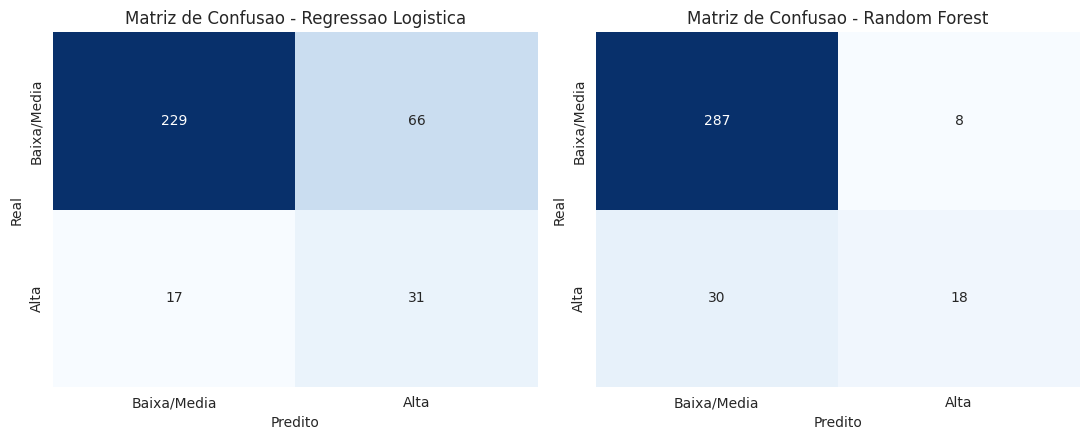

In [ ]:
# Matriz de confusao: tabela 2x2 que mostra, para cada modelo,
# quantos vinhos foram classificados corretamente e quantos foram confundidos
# (linhas = classe real, colunas = classe prevista)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (name, model) in zip(axes, models.items()):
    X_eval = X_test_scaled if name == "Regressao Logistica" else X_test
    y_pred = model.predict(X_eval)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Baixa/Media", "Alta"], yticklabels=["Baixa/Media", "Alta"])
    ax.set_title("Matriz de Confusao - " + name)
    ax.set_xlabel("Predito")
    ax.set_ylabel("Real")
plt.tight_layout()
plt.savefig("results/06_matrizes_confusao.png", dpi=120)
plt.show()


### 5.2 Validacao cruzada estratificada (5-fold)

Um unico split pode ser sensivel a sorte da divisao. Para uma comparacao mais robusta entre os modelos, usamos 5-fold estratificado sobre toda a base.

In [ ]:
# --------------------------------------------------------------
# Validacao cruzada: em vez de um unico split treino/teste, dividimos a base
# em 5 pedacos ("folds"). Cada modelo e treinado 5 vezes, cada vez usando 4 pedacos
# para treinar e 1 pedaco diferente para testar. No final, tiramos a media e o
# desvio padrao das 5 rodadas -- um resultado bem mais confiavel que um unico split.
# --------------------------------------------------------------

# shuffle=True embaralha os dados antes de dividir; StratifiedKFold garante que
# a proporcao 86%/14% das classes seja mantida em cada um dos 5 pedacos
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

cv_results = {}
for name in models:
    if name == "Regressao Logistica":
        # make_pipeline encadeia a padronizacao + o modelo num unico objeto.
        # Isso garante que, em CADA uma das 5 rodadas, o scaler seja recalculado
        # so com os dados de treino daquela rodada (evita "vazar" informacao do teste)
        pipe = make_pipeline(StandardScaler(), LogisticRegression(class_weight="balanced", random_state=RANDOM_STATE, max_iter=1000))
    else:
        pipe = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE)

    # cross_validate treina e avalia o modelo nas 5 rodadas automaticamente,
    # devolvendo um array com o resultado de cada metrica em cada rodada
    scores = cross_validate(pipe, X, y, cv=cv, scoring=scoring)

    row = {}
    for m in scoring:
        row[m + "_mean"] = scores["test_" + m].mean()  # media das 5 rodadas
        row[m + "_std"] = scores["test_" + m].std()    # o quanto o resultado variou entre rodadas
    cv_results[name] = row

cv_df = pd.DataFrame(cv_results).T.round(3)
cv_df.to_csv("results/05b_metricas_cv_5fold.csv")
cv_df[[c for c in cv_df.columns if "_mean" in c]]


,accuracy_mean,precision_mean,recall_mean,f1_mean,roc_auc_mean
Regressao Logistica,0.778,0.366,0.799,0.501,0.875
Random Forest,0.915,0.825,0.510,0.626,0.934


Comparacao: a validacao cruzada confirma (com desvio padrao) qual modelo generaliza melhor, em vez de depender de um unico split. Use a tabela de medias acima como a referencia oficial de comparacao entre Regressao Logistica e Random Forest para o relatorio final.

## 6. Interpretacao dos Resultados

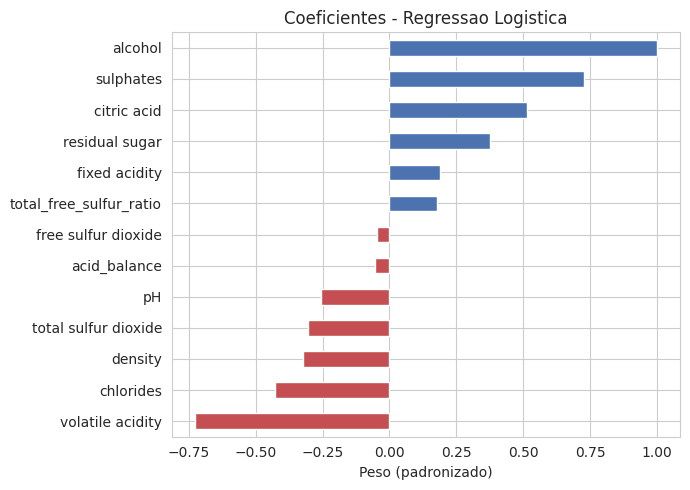

In [ ]:
# Coeficientes da Regressao Logistica: cada coeficiente mostra o quanto (e em que direcao)
# aquela variavel empurra a previsao para "Alta Qualidade" quando ela aumenta
# (valores positivos empurram para Alta, negativos empurram para Baixa/Media)
coef_df = pd.Series(log_reg.coef_[0], index=engineered_cols).sort_values()
plt.figure(figsize=(7, 5))
coef_df.plot(kind="barh", color=["#c44e52" if v < 0 else "#4c72b0" for v in coef_df])
plt.title("Coeficientes - Regressao Logistica")
plt.xlabel("Peso (padronizado)")
plt.tight_layout()
plt.savefig("results/07_coeficientes_logreg.png", dpi=120)
plt.show()


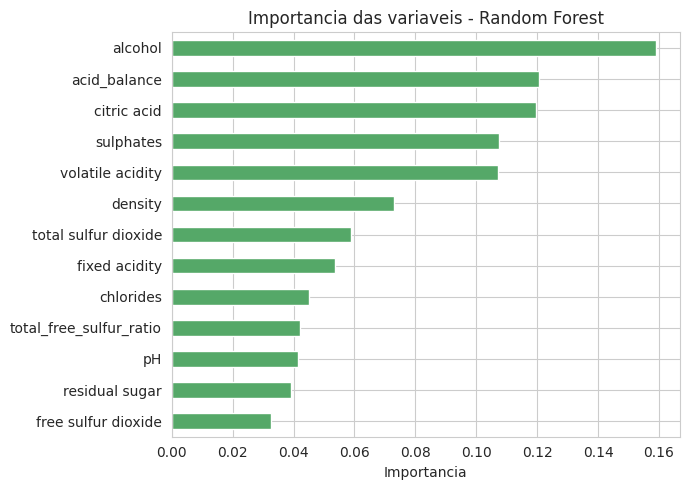

In [ ]:
# Importancia das variaveis na Random Forest: mede o quanto cada variavel contribuiu,
# em media, para reduzir o erro das arvores (nao indica direcao, so o "peso" de cada uma)
importances = pd.Series(rf.feature_importances_, index=engineered_cols).sort_values()
plt.figure(figsize=(7, 5))
importances.plot(kind="barh", color="#55a868")
plt.title("Importancia das variaveis - Random Forest")
plt.xlabel("Importancia")
plt.tight_layout()
plt.savefig("results/08_importancia_rf.png", dpi=120)
plt.show()


Principais pontos para discussao executiva:

1. Alcool e a variavel mais associada a notas altas - sugere que ajustar o processo de fermentacao para maior teor alcoolico controlado pode favorecer a qualidade percebida.
2. Acidez volatil alta tende a puxar a qualidade para baixo - e um indicador direto de defeito de producao (contaminacao acetica) e um ponto de controle de qualidade acionavel.
3. Sulfatos e o equilibrio de SO2 livre/total tem papel na conservacao e podem impactar indiretamente a percepcao sensorial ao longo do tempo.
4. Implicacao para producao: priorizar monitoramento de acidez volatil e teor alcoolico como indicadores precoces de qualidade, complementando (nao substituindo) a avaliacao sensorial.
5. Desbalanceamento de classes (~14% de vinhos de alta qualidade) e uma limitacao real do problema, nao so da amostra - a recall da classe minoritaria deve ser acompanhada de perto em producao, pois e mais custoso deixar de identificar um vinho de alta qualidade (ou aprovar um de baixa) do que o inverso, dependendo do caso de uso.